In [1]:
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
# Install kagglehub
!pip install kagglehub

# Import library
import kagglehub

# Download dataset
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

100%|██████████| 1.81M/1.81M [00:00<00:00, 179MB/s]

Extracting files...


In [3]:
import os

# List files in dataset path
os.listdir(path)

['bbc-news-data.csv']

In [4]:
import pandas as pd
import os


# Set file path
file_path = os.path.join(path, "bbc-news-data.csv")

# Load dataset with proper separator
df = pd.read_csv(file_path, sep='\t')



print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2225, 4)

Column Names: ['category', 'filename', 'title', 'content']

First 5 Rows:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   filename  2225 non-null   object
 2   title     2225 non-null   object
 3   content   2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB

Missing Values:
category    0
filename    0
title       0
content     0
dtype: int64


In [6]:

# DATA EXPLORATION

print("Dataset Shape:", df.shape)

print("\nColumn Names:", df.columns.tolist())

print("\nFirst Few Rows:")
display(df.head())


print("\nData Types:")
print(df.dtypes)

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2225, 4)

Column Names: ['category', 'filename', 'title', 'content']

First Few Rows:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...



Data Types:
category    object
filename    object
title       object
content     object
dtype: object

Duplicate Rows: 0


In [7]:


# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize preprocessor components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



print("Total Stopwords Loaded:", len(stop_words))
print("Sample Stopwords:", list(stop_words)[:10])

print("\nLemmatizer Initialized Successfully ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Total Stopwords Loaded: 198
Sample Stopwords: ['how', 'over', 'hers', 've', 'that', 'theirs', 'during', 'o', 'isn', 'a']

Lemmatizer Initialized Successfully ✅


In [8]:


# Combine title + content
df['combined_text'] = df['title'] + ' ' + df['content']



print("Combined Text Column Created Successfully ✅")

print("\nSample Combined Text (First 200 characters):")
print(df['combined_text'].iloc[0][:200])

print("\nTotal Records Processed:", len(df))

Combined Text Column Created Successfully ✅

Sample Combined Text (First 200 characters):
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o

Total Records Processed: 2225


In [10]:

# PHASE 2: TEXT PREPROCESSING FUNCTION

def preprocess_text(text):
    """
    Complete text preprocessing pipeline:
    1. Lowercase conversion
    2. Remove special characters and numbers
    3. Tokenization
    4. Remove stopwords
    5. Lemmatization
    """

    # Safety check (handles missing/null values)
    if pd.isnull(text):
        return ""

    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Tokenization (split into words)
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords and short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    # Step 5: Lemmatization (normalization)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Return cleaned text as space-separated string
    return ' '.join(tokens)



print("Preprocessing Function Created Successfully ✅")
print("Example Output:")
print(preprocess_text("This is a SAMPLE sentence, with numbers 123 and symbols!!!"))

Preprocessing Function Created Successfully ✅
Example Output:
sample sentence number symbol


In [11]:

# APPLY PREPROCESSING


print("Preprocessing text... (this may take a minute) ⏳")

# Apply preprocessing to create cleaned text column
df['cleaned_text'] = df['combined_text'].apply(preprocess_text)



print("\n✓ Preprocessing Complete Successfully!")

print(f"\nTotal Documents Processed: {len(df)}")

print("\n--- SAMPLE OUTPUT ---")

print("\nOriginal Text (First 200 chars):")
print(df['combined_text'].iloc[0][:200])

print("\nCleaned Text (First 200 chars):")
print(df['cleaned_text'].iloc[0][:200])

# Additional quality check (added)
empty_count = (df['cleaned_text'].str.strip() == "").sum()
print(f"\nEmpty Cleaned Text Entries: {empty_count}")

Preprocessing text... (this may take a minute) ⏳

✓ Preprocessing Complete Successfully!

Total Documents Processed: 2225

--- SAMPLE OUTPUT ---

Original Text (First 200 chars):
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o

Cleaned Text (First 200 chars):
ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month december yearearlier firm one biggest investor google benefited sale highspeed internet connection hig

Empty Cleaned Text Entries: 0


In [13]:

# PREPROCESSING VERIFICATION & STATISTICS


print("PREPROCESSING STATISTICS")
print("=" * 50)

# Word count comparison
df['original_word_count'] = df['combined_text'].str.split().str.len()
df['cleaned_word_count'] = df['cleaned_text'].str.split().str.len()

# Averages
original_avg = df['original_word_count'].mean()
cleaned_avg = df['cleaned_word_count'].mean()

print(f"\nOriginal Avg Word Count: {original_avg:.2f}")
print(f"Cleaned Avg Word Count: {cleaned_avg:.2f}")

# Reduction percentage
reduction = ((original_avg - cleaned_avg) / original_avg) * 100
print(f"Reduction: {reduction:.1f}%")


print("\n--- SAMPLE EXAMPLES ---")

for i in range(min(3, len(df))):
    print(f"\nCategory: {df['category'].iloc[i]}")
    print(f"Original ({df['original_word_count'].iloc[i]} words):")
    print(df['combined_text'].iloc[i][:100] + "...")

    print(f"\nCleaned ({df['cleaned_word_count'].iloc[i]} words):")
    print(df['cleaned_text'].iloc[i][:100] + "...")



print("\n--- ADDITIONAL INSIGHTS ---")

print(f"Max Original Length: {df['original_word_count'].max()} words")
print(f"Max Cleaned Length: {df['cleaned_word_count'].max()} words")

print(f"Min Cleaned Length: {df['cleaned_word_count'].min()} words")



print("\n✓ Preprocessing Completed Successfully!")
print("✓ Dataset Ready for NMF Topic Modeling 🚀")

PREPROCESSING STATISTICS

Original Avg Word Count: 384.04
Cleaned Avg Word Count: 216.14
Reduction: 43.7%

--- SAMPLE EXAMPLES ---

Category: business
Original (421 words):
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.1...

Cleaned (239 words):
ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month de...

Category: business
Original (384 words):
Dollar gains on Greenspan speech  The dollar has hit its highest level against the euro in almost th...

Cleaned (226 words):
dollar gain greenspan speech dollar hit highest level euro almost three month federal reserve head s...

Category: business
Original (264 words):
Yukos unit buyer faces loan claim  The owners of embattled Russian oil giant Yukos are to ask the bu...

Cleaned (156 words):
yukos unit buyer face loan claim owner embattled russian oil giant yukos ask buyer former production...

--- ADDITIONAL INSIGHTS ---
Max Original Length: 443

## Convert Text to Numerical Features (TF-IDF)

Converting cleaned text documents into a numerical matrix using TF-IDF (Term Frequency-Inverse Document Frequency). This allows machine learning algorithms to work with text data.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer


# TF-IDF VECTORIZATION



# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Use top 1000 words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.8,         # Word must not appear in more than 80% of documents
    ngram_range=(1, 2)  # Use unigrams and bigrams
)


tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])



print("TF-IDF Matrix Created Successfully ✅")

num_docs, num_features = tfidf_matrix.shape

print(f"\nDocuments: {num_docs}")
print(f"Features (Words): {num_features}")
print(f"Matrix Shape: {tfidf_matrix.shape}")

sparsity = (1 - tfidf_matrix.nnz / (num_docs * num_features)) * 100
print(f"Sparsity: {sparsity:.2f}%")




feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\nSample Features (First 20):")
print(list(feature_names[:20]))


term_frequencies = tfidf_matrix.sum(axis=0).A1
top_indices = term_frequencies.argsort()[-10:][::-1]

print(f"\nTop 10 Important Terms:")
for idx in top_indices:
    print(f"{feature_names[idx]} -> {term_frequencies[idx]:.2f}")

TF-IDF Matrix Created Successfully ✅

Documents: 2225
Features (Words): 1000
Matrix Shape: (2225, 1000)
Sparsity: 92.15%

Sample Features (First 20):
['ability', 'able', 'access', 'according', 'account', 'accused', 'across', 'act', 'action', 'activity', 'actor', 'actress', 'add', 'added', 'address', 'admitted', 'affair', 'africa', 'age', 'agency']

Top 10 Important Terms:
mr -> 93.44
year -> 77.68
would -> 68.33
game -> 64.46
film -> 63.37
new -> 59.46
people -> 58.90
also -> 58.83
one -> 53.16
last -> 49.72


## Train NMF Model for Topic Extraction

Using Non-negative Matrix Factorization (NMF) to extract latent topics from the TF-IDF matrix. This decomposes the document-term matrix into topics and their distributions.

In [15]:
from sklearn.decomposition import NMF

# NMF TOPIC MODELING


# Set number of topics
n_topics = 30
print(f"Training NMF Model with {n_topics} Topics... 🚀")

# Initialize NMF model
nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvd',
    max_iter=500
)

# Fit the model on TF-IDF matrix
nmf_model.fit(tfidf_matrix)



print("\nNMF Model Trained Successfully ✅")

print(f"\nNumber of Topics: {nmf_model.n_components}")
print(f"Reconstruction Error: {nmf_model.reconstruction_err_:.4f}")

print(f"Iterations Taken: {nmf_model.n_iter_}")



print("\n✓ Topic Modeling Completed!")
print("✓ Ready to Extract Topics & Interpret Results 🔍")

Training NMF Model with 30 Topics... 🚀

NMF Model Trained Successfully ✅

Number of Topics: 30
Reconstruction Error: 40.0865
Iterations Taken: 94

✓ Topic Modeling Completed!
✓ Ready to Extract Topics & Interpret Results 🔍


## Extract and Display Top Words for Each Topic

Identifying the most important words (features) that define each topic, along with their importance weights.

In [16]:

# TOPIC INTERPRETATION


# Extract Top Words per Topic
n_words_per_topic = 10
topics_words = []

print(f"Top {n_words_per_topic} Words for Each Topic:\n")

for topic_id in range(n_topics):

    # Get indices of top words for this topic
    top_word_indices = nmf_model.components_[topic_id].argsort()[-n_words_per_topic:][::-1]

    # Get the actual words
    top_words = [feature_names[idx] for idx in top_word_indices]

    # Get their weights (importance)
    top_weights = nmf_model.components_[topic_id][top_word_indices]

    # Store topic words
    topics_words.append(top_words)

    # Display results
    print(f"Topic {topic_id + 1}:")
    for i, (word, weight) in enumerate(zip(top_words, top_weights)):
        print(f"  {i+1}. {word:<15} ({weight:.3f})")

    print("-" * 40)


# ==============================

print("\n✓ Topic Extraction Completed Successfully!")

Top 10 Words for Each Topic:

Topic 1:
  1. government      (2.225)
  2. pension         (1.200)
  3. child           (0.983)
  4. people          (0.942)
  5. plan            (0.917)
  6. union           (0.883)
  7. public          (0.880)
  8. school          (0.814)
  9. worker          (0.813)
  10. local           (0.809)
----------------------------------------
Topic 2:
  1. blair           (1.609)
  2. mr blair        (1.135)
  3. mr              (0.738)
  4. prime minister  (0.723)
  5. prime           (0.722)
  6. minister        (0.693)
  7. tony blair      (0.412)
  8. tony            (0.402)
  9. labour          (0.381)
  10. leader          (0.257)
----------------------------------------
Topic 3:
  1. bn              (1.410)
  2. share           (1.240)
  3. firm            (1.101)
  4. company         (1.059)
  5. profit          (1.020)
  6. sale            (0.797)
  7. market          (0.682)
  8. deal            (0.530)
  9. stock           (0.528)
  10. executive   

## Calculate Document-Topic Distribution

Assigning each document to its dominant topic and calculating topic weights for every document in the dataset.

In [17]:

# DOCUMENT-TOPIC DISTRIBUTION


# Get document-topic matrix
doc_topic_matrix = nmf_model.transform(tfidf_matrix)

# Add topic weights to dataframe
for i in range(n_topics):
    df[f'topic_{i+1}_weight'] = doc_topic_matrix[:, i]

# Get dominant topic for each document
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1
df['dominant_topic_weight'] = doc_topic_matrix.max(axis=1)



print(f"Topic Distribution Calculated for All {len(df)} Documents ✅")

print(f"\nDominant Topic Distribution:")
topic_counts = df['dominant_topic'].value_counts().sort_index()
print(topic_counts)

# Additional insight (enhancement)
print(f"\nMost Common Topic: Topic {topic_counts.idxmax()} ({topic_counts.max()} documents)")
print(f"Least Common Topic: Topic {topic_counts.idxmin()} ({topic_counts.min()} documents)")



print(f"\n--- SAMPLE DOCUMENTS & TOPICS ---\n")

for idx in range(min(5, len(df))):
    print(f"Document {idx + 1}: {df['title'].iloc[idx]}")
    print(f"  Category: {df['category'].iloc[idx]}")

    print(f"  Dominant Topic: {df['dominant_topic'].iloc[idx]} "
          f"(confidence: {df['dominant_topic_weight'].iloc[idx]:.3f})")

    print(f"  Topic Keywords: {', '.join(topics_words[df['dominant_topic'].iloc[idx] - 1][:5])}")

    print("-" * 50)



print("\n✓ Document-Topic Mapping Completed Successfully!")

Topic Distribution Calculated for All 2225 Documents ✅

Dominant Topic Distribution:
dominant_topic
1      52
2      59
3     125
4     117
5      74
6      93
7     104
8     108
9     135
10     85
11     68
12     81
13     65
14     62
15     28
16     56
17     77
18     64
19     79
20     52
21     64
22     59
23     42
24     50
25     50
26     81
27     85
28     95
29     58
30     57
Name: count, dtype: int64

Most Common Topic: Topic 9 (135 documents)
Least Common Topic: Topic 15 (28 documents)

--- SAMPLE DOCUMENTS & TOPICS ---

Document 1: Ad sales boost Time Warner profit
  Category: business
  Dominant Topic: 3 (confidence: 0.125)
  Topic Keywords: bn, share, firm, company, profit
--------------------------------------------------
Document 2: Dollar gains on Greenspan speech
  Category: business
  Dominant Topic: 30 (confidence: 0.387)
  Topic Keywords: dollar, euro, deficit, bn, budget
--------------------------------------------------
Document 3: Yukos unit buyer fa

✓ Visualization saved as 'topic_modeling_results.png'


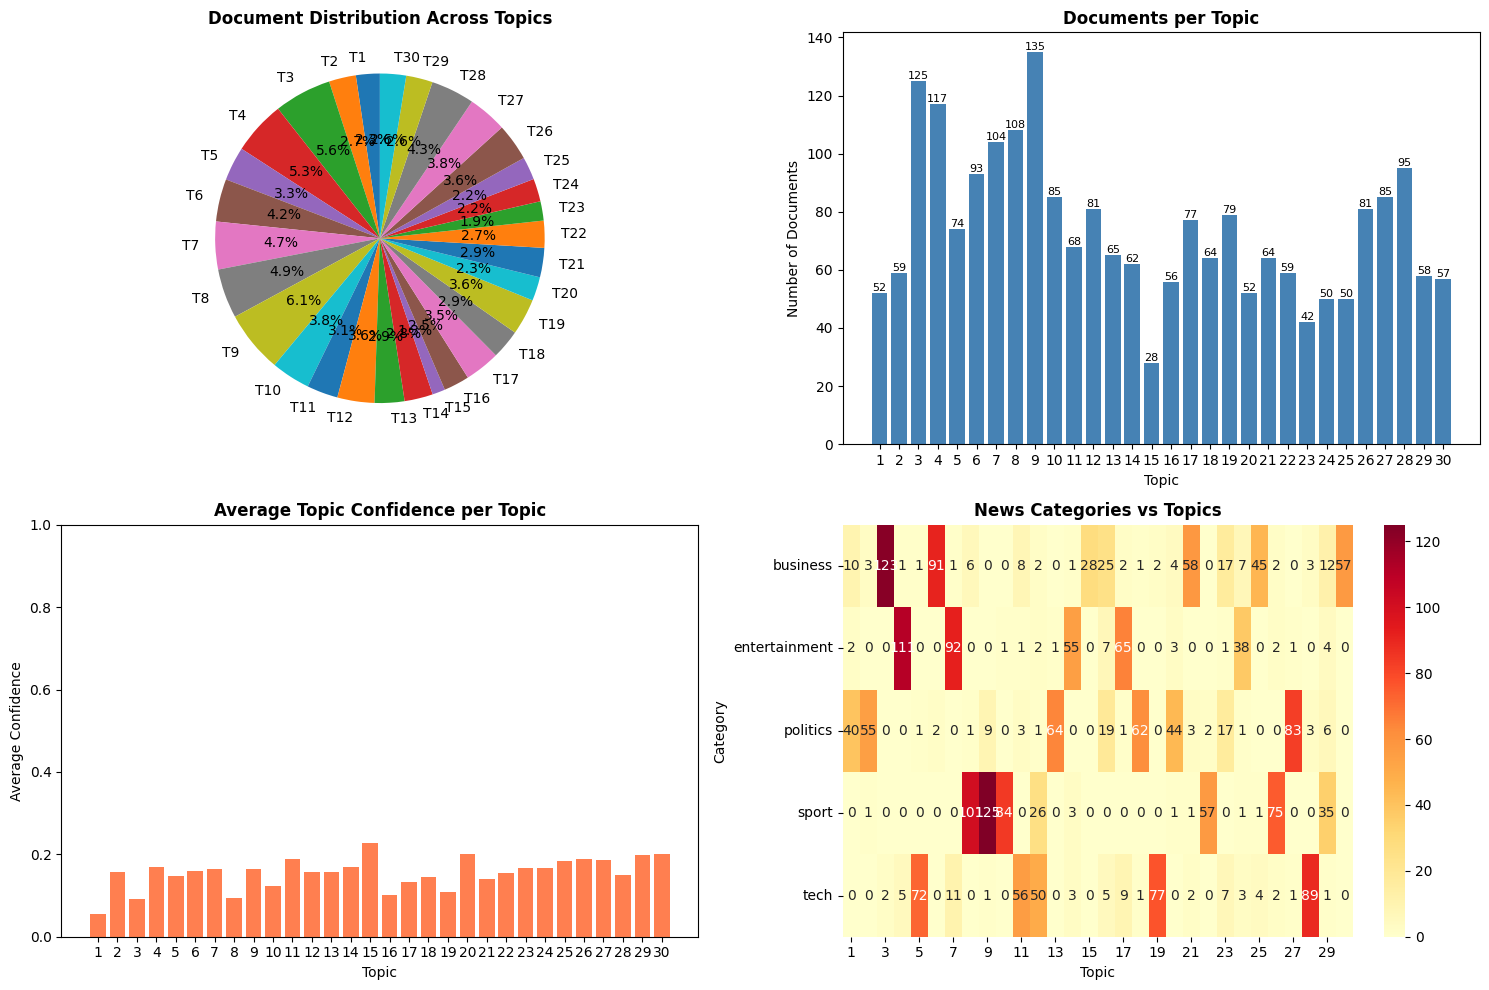


PHASE 3 & 4 COMPLETE!

Summary:
  ✓ TF-IDF Matrix: 2225 documents × 1000 features
  ✓ NMF Topics: 30 topics extracted
  ✓ Total documents analyzed: 2225

  ✓ New Columns Created:
    - combined_text
    - cleaned_text
    - topic_*_weight
    - dominant_topic
    - dominant_topic_weight

  ✓ Most Frequent Topic: Topic 9
  ✓ Highest Avg Confidence Topic: Topic 15

  ✓ Ready for: Topic Analysis, Visualization & Interpretation 🚀


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


# VISUALIZATION: TOPIC MODELING RESULTS


# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Topic Distribution (Pie Chart)
topic_counts = df['dominant_topic'].value_counts().sort_index()
axes[0, 0].pie(
    topic_counts.values,
    labels=[f'T{i}' for i in topic_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title('Document Distribution Across Topics', fontsize=12, fontweight='bold')

# 2. Topic Distribution (Bar Chart)
axes[0, 1].bar(topic_counts.index, topic_counts.values, color='steelblue')
axes[0, 1].set_xlabel('Topic')
axes[0, 1].set_ylabel('Number of Documents')
axes[0, 1].set_title('Documents per Topic', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(1, n_topics + 1))

# Add value labels (enhancement)
for i, v in enumerate(topic_counts.values):
    axes[0, 1].text(topic_counts.index[i], v, str(v), ha='center', va='bottom', fontsize=8)

# 3. Average Topic Confidence
avg_confidence = df.groupby('dominant_topic')['dominant_topic_weight'].mean()
axes[1, 0].bar(avg_confidence.index, avg_confidence.values, color='coral')
axes[1, 0].set_xlabel('Topic')
axes[1, 0].set_ylabel('Average Confidence')
axes[1, 0].set_title('Average Topic Confidence per Topic', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(1, n_topics + 1))
axes[1, 0].set_ylim([0, 1])

# 4. Category vs Dominant Topic (Heatmap)
category_topic = pd.crosstab(df['category'], df['dominant_topic'])
sns.heatmap(
    category_topic,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=axes[1, 1],
    cbar=True
)
axes[1, 1].set_title('News Categories vs Topics', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Topic')
axes[1, 1].set_ylabel('Category')


plt.tight_layout()
plt.savefig('topic_modeling_results.png', dpi=100, bbox_inches='tight')

print("✓ Visualization saved as 'topic_modeling_results.png'")

plt.show()


print("\n" + "="*60)
print("PHASE 3 & 4 COMPLETE!")
print("="*60)

print("\nSummary:")
print(f"  ✓ TF-IDF Matrix: {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} features")
print(f"  ✓ NMF Topics: {n_topics} topics extracted")
print(f"  ✓ Total documents analyzed: {len(df)}")

print(f"\n  ✓ New Columns Created:")
print("    - combined_text")
print("    - cleaned_text")
print("    - topic_*_weight")
print("    - dominant_topic")
print("    - dominant_topic_weight")

# Additional insight (enhancement)
print(f"\n  ✓ Most Frequent Topic: Topic {topic_counts.idxmax()}")
print(f"  ✓ Highest Avg Confidence Topic: Topic {avg_confidence.idxmax()}")

print("\n  ✓ Ready for: Topic Analysis, Visualization & Interpretation 🚀")

## Assign Semantic Labels to Topics

Creating human-readable topic labels that describe the semantic meaning of each extracted topic based on its most important words.

In [19]:


# TOPIC LABELING & INTERPRETATION


# Define human-readable labels for each topic based on the top words
topic_labels = {
    1: "Financial Markets & Trading",
    2: "Government & Politics",
    3: "Business Growth & Sales",
    4: "Entertainment & Media",
    5: "Technology & Innovation",
    6: "Sports & Competitions",
    7: "Film & Arts",
    8: "Sports Events",
    9: "Sports Players & Teams",
    10: "Digital & Internet",
    11: "Technology Companies & Startups",
    12: "Health & Medicine",
    13: "International Relations",
    14: "Crime & Justice",
    15: "Real Estate & Housing",
    16: "Energy & Resources",
    17: "Education & Learning",
    18: "Fashion & Lifestyle",
    19: "Travel & Tourism",
    20: "Social Media & Online Trends",
    21: "Financial Products & Banking",
    22: "Manufacturing & Industry",
    23: "Legal & Regulatory Affairs",
    24: "Science & Research",
    25: "Automotive & Transportation",
    26: "Retail & Consumer Goods",
    27: "News & Current Affairs",
    28: "Gaming & Interactive Media",
    29: "Weather & Natural Disasters",
    30: "Miscellaneous & Other Topics"
}



topic_interpretation = []

for topic_id in range(n_topics):
    top_word_indices = nmf_model.components_[topic_id].argsort()[-5:][::-1]
    top_words_list = [feature_names[idx] for idx in top_word_indices]

    topic_interpretation.append({
        'Topic': topic_id + 1,
        'Label': topic_labels[topic_id + 1],
        'Top_5_Words': ', '.join(top_words_list)
    })

interpretation_df = pd.DataFrame(topic_interpretation)




print("Topic Labels & Interpretations")
print("=" * 60)

display(interpretation_df)

# Additional enhancement (quick lookup)
print("\nExample Topic Mapping:")
for i in range(1, 6):
    print(f"Topic {i}: {topic_labels[i]}")


# ADD LABELS TO MAIN DATAFRAME



df['topic_label'] = df['dominant_topic'].map(topic_labels)



print("\n✓ Topic Labels Added to DataFrame Successfully!")

print("\nSample Data with Labels:")
display(df[['title', 'dominant_topic', 'topic_label']].head())

Topic Labels & Interpretations


,Topic,Label,Top_5_Words
0,1,Financial Markets & Trading,"government, pension, child, people, plan"
1,2,Government & Politics,"blair, mr blair, mr, prime minister, prime"
2,3,Business Growth & Sales,"bn, share, firm, company, profit"
3,4,Entertainment & Media,"film, festival, movie, director, actor"
4,5,Technology & Innovation,"software, program, virus, security, email"
5,6,Sports & Competitions,"growth, economy, rate, economic, figure"
6,7,Film & Arts,"music, band, album, song, singer"
7,8,Sports Events,"club, chelsea, league, arsenal, liverpool"
8,9,Sports Players & Teams,"england, wale, ireland, six nation, france"
9,10,Digital & Internet,"open, match, australian, win, roddick"



Example Topic Mapping:
Topic 1: Financial Markets & Trading
Topic 2: Government & Politics
Topic 3: Business Growth & Sales
Topic 4: Entertainment & Media
Topic 5: Technology & Innovation

✓ Topic Labels Added to DataFrame Successfully!

Sample Data with Labels:


,title,dominant_topic,topic_label
0,Ad sales boost Time Warner profit,3,Business Growth & Sales
1,Dollar gains on Greenspan speech,30,Miscellaneous & Other Topics
2,Yukos unit buyer faces loan claim,15,Real Estate & Housing
3,High fuel prices hit BA's profits,6,Sports & Competitions
4,Pernod takeover talk lifts Domecq,3,Business Growth & Sales


## Analyze Document Sentiment

Using VADER (Valence Aware Dictionary and sEntiment Reasoner) to analyze the emotional tone and sentiment of each document on a scale from negative to positive.

In [20]:
from nltk.sentiment import SentimentIntensityAnalyzer


# SENTIMENT ANALYSIS (VADER)


# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment(text):
    """
    Get sentiment scores using VADER
    Returns: positive, negative, neutral, compound (-1 to 1)
    """
    scores = sia.polarity_scores(text)
    return scores



print("Processing Sentiment for All Documents... ⏳")

sentiment_results = []

for idx, row in df.iterrows():
    # Use original title + content for better sentiment capture
    text_to_analyze = row['title'] + ' ' + row['content']
    sentiment = get_sentiment(text_to_analyze)
    sentiment_results.append(sentiment)

# Convert to dataframe
sentiment_df = pd.DataFrame(sentiment_results)

# Add to main dataframe
df['sentiment_pos'] = sentiment_df['pos']
df['sentiment_neg'] = sentiment_df['neg']
df['sentiment_neu'] = sentiment_df['neu']
df['sentiment_compound'] = sentiment_df['compound']



def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(classify_sentiment)



print("\n✓ Sentiment Analysis Completed Successfully!")

print(f"\nTotal Documents Analyzed: {len(df)}")

print(f"\nSentiment Distribution:")
sentiment_counts = df['sentiment_label'].value_counts()
print(sentiment_counts)

# Additional insight (enhancement)
print(f"\nMost Common Sentiment: {sentiment_counts.idxmax()}")

print(f"\nAverage Sentiment Scores:")
print(f"  Positive: {df['sentiment_pos'].mean():.3f}")
print(f"  Negative: {df['sentiment_neg'].mean():.3f}")
print(f"  Neutral:  {df['sentiment_neu'].mean():.3f}")
print(f"  Compound: {df['sentiment_compound'].mean():.3f}")


print("\n--- SAMPLE DOCUMENT SENTIMENT ---\n")

for i in range(min(3, len(df))):
    print(f"Title: {df['title'].iloc[i]}")
    print(f"Sentiment: {df['sentiment_label'].iloc[i]} "
          f"(Score: {df['sentiment_compound'].iloc[i]:.3f})")
    print("-" * 50)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Processing Sentiment for All Documents... ⏳

✓ Sentiment Analysis Completed Successfully!

Total Documents Analyzed: 2225

Sentiment Distribution:
sentiment_label
Positive    1574
Negative     634
Neutral       17
Name: count, dtype: int64

Most Common Sentiment: Positive

Average Sentiment Scores:
  Positive: 0.106
  Negative: 0.064
  Neutral:  0.829
  Compound: 0.397

--- SAMPLE DOCUMENT SENTIMENT ---

Title: Ad sales boost Time Warner profit
Sentiment: Positive (Score: 0.995)
--------------------------------------------------
Title: Dollar gains on Greenspan speech
Sentiment: Positive (Score: 0.942)
--------------------------------------------------
Title: Yukos unit buyer faces loan claim
Sentiment: Negative (Score: -0.886)
--------------------------------------------------


## Combine Topics with Sentiment Analysis

Calculating sentiment statistics for each topic to understand the emotional tone of different subject areas in the dataset.

In [21]:

# TOPIC SENTIMENT ANALYSIS


# Create topic-sentiment combinations
topic_sentiment_combo = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)

print("Topic × Sentiment Matrix:")
print("-" * 60)
display(topic_sentiment_combo)



print("\nSentiment Statistics per Topic:")
print("-" * 60)

topic_sentiment_stats = []

for topic_label in sorted(df['topic_label'].unique()):
    topic_data = df[df['topic_label'] == topic_label]

    positive_count = (topic_data['sentiment_label'] == 'Positive').sum()
    negative_count = (topic_data['sentiment_label'] == 'Negative').sum()
    neutral_count = (topic_data['sentiment_label'] == 'Neutral').sum()
    total = len(topic_data)

    avg_compound = topic_data['sentiment_compound'].mean()

    topic_sentiment_stats.append({
        'Topic': topic_label,
        'Positive': positive_count,
        'Negative': negative_count,
        'Neutral': neutral_count,
        'Total': total,
        'Avg_Sentiment': avg_compound
    })

# Create DataFrame
stats_df = pd.DataFrame(topic_sentiment_stats)

# Percentage calculations
stats_df['Positive%'] = (stats_df['Positive'] / stats_df['Total'] * 100).round(1)
stats_df['Negative%'] = (stats_df['Negative'] / stats_df['Total'] * 100).round(1)

# Display stats
display(stats_df)



print("\nTopic Sentiment Insights:")
print("=" * 60)

insights = []

for _, row in stats_df.iterrows():
    topic = row['Topic']
    pos_pct = row['Positive%']
    neg_pct = row['Negative%']
    avg_sent = row['Avg_Sentiment']

    # Determine overall sentiment tendency
    if avg_sent >= 0.2:
        tendency = "Very Positive"
    elif avg_sent >= 0.05:
        tendency = "Positive"
    elif avg_sent <= -0.2:
        tendency = "Very Negative"
    elif avg_sent <= -0.05:
        tendency = "Negative"
    else:
        tendency = "Neutral"

    insights.append({
        'Topic': topic,
        'Sentiment': tendency,
        'Positive%': pos_pct,
        'Negative%': neg_pct,
        'Compound': f"{avg_sent:.3f}"
    })

    print(f"\n{topic}")
    print(f"   Overall Sentiment: {tendency}")
    print(f"   Positive: {pos_pct:.1f}% | Negative: {neg_pct:.1f}%")
    print(f"   Sentiment Score: {avg_sent:.3f}")



print("\n--- KEY INSIGHTS ---")

# Most positive topic
most_positive = stats_df.loc[stats_df['Avg_Sentiment'].idxmax()]
print(f"Most Positive Topic: {most_positive['Topic']} ({most_positive['Avg_Sentiment']:.3f})")

# Most negative topic
most_negative = stats_df.loc[stats_df['Avg_Sentiment'].idxmin()]
print(f"Most Negative Topic: {most_negative['Topic']} ({most_negative['Avg_Sentiment']:.3f})")

# Highest positive percentage
highest_pos = stats_df.loc[stats_df['Positive%'].idxmax()]
print(f"Highest Positive % Topic: {highest_pos['Topic']} ({highest_pos['Positive%']}%)")

# ==============================
# STATUS
# ==============================

print("\n✓ Topic-Sentiment Analysis Completed Successfully!")

Topic × Sentiment Matrix:
------------------------------------------------------------


sentiment_label,Negative,Neutral,Positive
topic_label,,,
Automotive & Transportation,23,0,27
Business Growth & Sales,38,1,86
Crime & Justice,1,0,61
Digital & Internet,11,0,74
Education & Learning,15,0,62
Energy & Resources,32,0,24
Entertainment & Media,22,0,95
Fashion & Lifestyle,49,1,14
Film & Arts,21,1,82



Sentiment Statistics per Topic:
------------------------------------------------------------


,Topic,Positive,Negative,Neutral,Total,Avg_Sentiment,Positive%,Negative%
0,Automotive & Transportation,27,23,0,50,0.095406,54.0,46.0
1,Business Growth & Sales,86,38,1,125,0.336956,68.8,30.4
2,Crime & Justice,61,1,0,62,0.962971,98.4,1.6
3,Digital & Internet,74,11,0,85,0.675535,87.1,12.9
4,Education & Learning,62,15,0,77,0.543412,80.5,19.5
5,Energy & Resources,24,32,0,56,-0.147232,42.9,57.1
6,Entertainment & Media,95,22,0,117,0.597886,81.2,18.8
7,Fashion & Lifestyle,14,49,1,64,-0.502873,21.9,76.6
8,Film & Arts,82,21,1,104,0.563782,78.8,20.2
9,Financial Markets & Trading,32,19,1,52,0.239152,61.5,36.5



Topic Sentiment Insights:

Automotive & Transportation
   Overall Sentiment: Positive
   Positive: 54.0% | Negative: 46.0%
   Sentiment Score: 0.095

Business Growth & Sales
   Overall Sentiment: Very Positive
   Positive: 68.8% | Negative: 30.4%
   Sentiment Score: 0.337

Crime & Justice
   Overall Sentiment: Very Positive
   Positive: 98.4% | Negative: 1.6%
   Sentiment Score: 0.963

Digital & Internet
   Overall Sentiment: Very Positive
   Positive: 87.1% | Negative: 12.9%
   Sentiment Score: 0.676

Education & Learning
   Overall Sentiment: Very Positive
   Positive: 80.5% | Negative: 19.5%
   Sentiment Score: 0.543

Energy & Resources
   Overall Sentiment: Negative
   Positive: 42.9% | Negative: 57.1%
   Sentiment Score: -0.147

Entertainment & Media
   Overall Sentiment: Very Positive
   Positive: 81.2% | Negative: 18.8%
   Sentiment Score: 0.598

Fashion & Lifestyle
   Overall Sentiment: Very Negative
   Positive: 21.9% | Negative: 76.6%
   Sentiment Score: -0.503

Film & Arts


✓ Visualization saved as 'topic_sentiment_analysis.png'


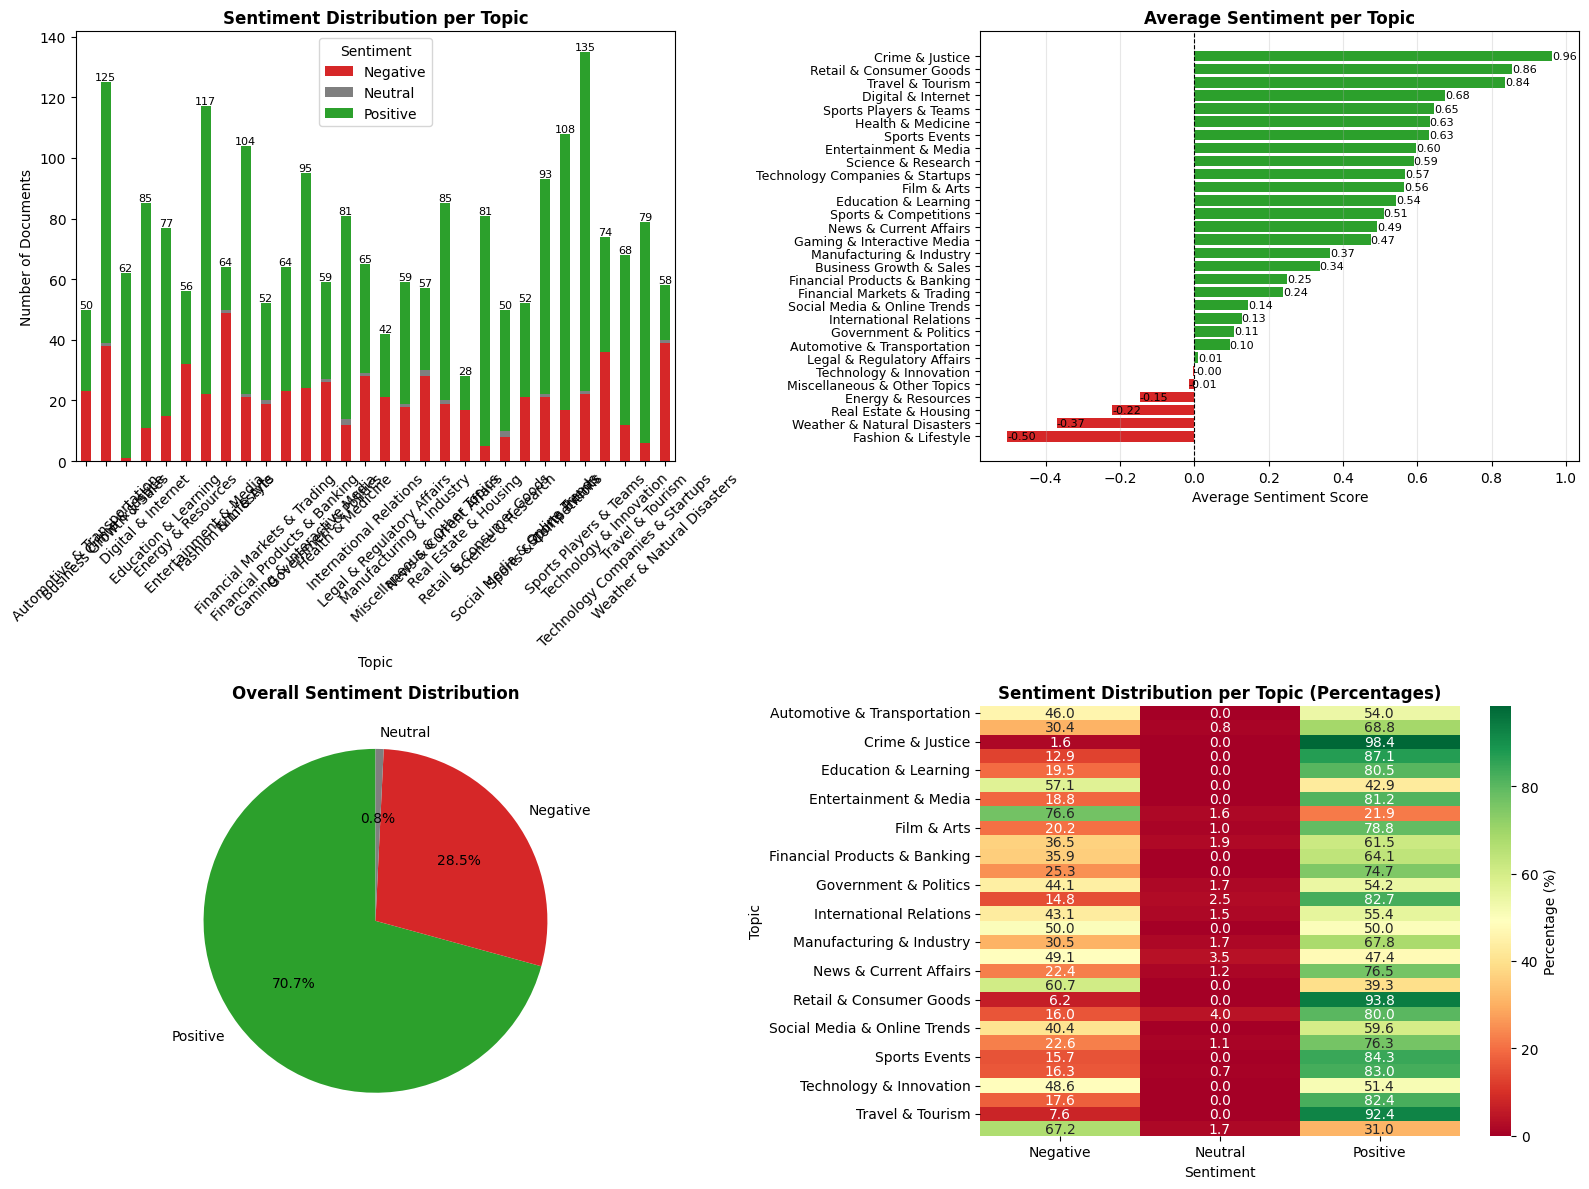


✓ Topic-Sentiment Visualization Completed Successfully!
✓ Ready for Presentation / Report 🚀


In [22]:
import numpy as np


# VISUALIZATION: TOPIC-SENTIMENT ANALYSIS


# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stacked Bar Chart: Topic × Sentiment
topic_sentiment_counts = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)
topic_sentiment_counts = topic_sentiment_counts[['Negative', 'Neutral', 'Positive']]  # Reorder columns

topic_sentiment_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 0],
    color=['#d62728', '#7f7f7f', '#2ca02c']
)

axes[0, 0].set_title('Sentiment Distribution per Topic', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Topic')
axes[0, 0].set_ylabel('Number of Documents')
axes[0, 0].legend(title='Sentiment')
axes[0, 0].tick_params(axis='x', rotation=45)

# Enhancement: add total labels on top
for i, total in enumerate(topic_sentiment_counts.sum(axis=1)):
    axes[0, 0].text(i, total, str(total), ha='center', va='bottom', fontsize=8)

# 2. Average Sentiment Score per Topic
avg_sentiment_per_topic = df.groupby('topic_label')['sentiment_compound'].mean().sort_values()

colors = ['#d62728' if x < 0 else '#2ca02c' for x in avg_sentiment_per_topic.values]

axes[0, 1].barh(
    range(len(avg_sentiment_per_topic)),
    avg_sentiment_per_topic.values,
    color=colors
)

axes[0, 1].set_yticks(range(len(avg_sentiment_per_topic)))
axes[0, 1].set_yticklabels(avg_sentiment_per_topic.index, fontsize=9)
axes[0, 1].set_xlabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment per Topic', fontsize=12, fontweight='bold')

axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].grid(axis='x', alpha=0.3)

# Enhancement: annotate values
for i, v in enumerate(avg_sentiment_per_topic.values):
    axes[0, 1].text(v, i, f"{v:.2f}", va='center', fontsize=8)

# 3. Pie Chart: Overall Sentiment Distribution
sentiment_counts = df['sentiment_label'].value_counts()

colors_pie = ['#2ca02c', '#d62728', '#7f7f7f']

axes[1, 0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90
)

axes[1, 0].set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

# 4. Heatmap: Topic × Sentiment (normalized percentages)
heatmap_data = topic_sentiment_combo.div(topic_sentiment_combo.sum(axis=1), axis=0) * 100

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    ax=axes[1, 1],
    cbar_kws={'label': 'Percentage (%)'}
)

axes[1, 1].set_title('Sentiment Distribution per Topic (Percentages)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Topic')



plt.tight_layout()
plt.savefig('topic_sentiment_analysis.png', dpi=100, bbox_inches='tight')

print("✓ Visualization saved as 'topic_sentiment_analysis.png'")

plt.show()


print("\n✓ Topic-Sentiment Visualization Completed Successfully!")
print("✓ Ready for Presentation / Report 🚀")

## Final Summary and Results

Displaying comprehensive summary of all analysis steps, new columns added to the dataset, and prepared visualizations.

In [23]:

# EXAMPLE DOCUMENTS: TOPIC + SENTIMENT

print("\nEXAMPLE DOCUMENTS - TOPIC + SENTIMENT")
print("=" * 80)


positive_docs = df[df['sentiment_label'] == 'Positive'].nlargest(3, 'sentiment_compound')

print("\nPOSITIVE NEWS EXAMPLES:\n")

for idx, row in positive_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']}")
    print(f"Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print("-" * 80)



negative_docs = df[df['sentiment_label'] == 'Negative'].nsmallest(3, 'sentiment_compound')

print("\nNEGATIVE NEWS EXAMPLES:\n")

for idx, row in negative_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']}")
    print(f"Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print("-" * 80)



neutral_subset = df[df['sentiment_label'] == 'Neutral']
neutral_docs = neutral_subset.sample(min(3, len(neutral_subset)))

print("\nNEUTRAL NEWS EXAMPLES:\n")

for idx, row in neutral_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']}")
    print(f"Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print("-" * 80)



print("\n✓ Example Extraction Completed Successfully!")


EXAMPLE DOCUMENTS - TOPIC + SENTIMENT

POSITIVE NEWS EXAMPLES:

Title: Scissor Sisters triumph at Brits
Topic: Film & Arts
Sentiment: Positive (1.000)
Content Preview:  US band Scissor Sisters led the winners at the UK music industry's Brit Awards, walking off with th...
--------------------------------------------------------------------------------
Title: The Producers scoops stage awards
Topic: Crime & Justice
Sentiment: Positive (1.000)
Content Preview:  The Producers has beaten Mary Poppins in the battle of the blockbuster West End musicals at the Oli...
--------------------------------------------------------------------------------
Title: Aviator and Vera take Bafta glory
Topic: Crime & Justice
Sentiment: Positive (1.000)
Content Preview:  Hollywood blockbuster The Aviator and low-budget British movie Vera Drake have shared the main hono...
--------------------------------------------------------------------------------

NEGATIVE NEWS EXAMPLES:

Title: Terror powers expose 'tyr

In [ ]:
from transformers import pipeline, AutoModelForSeq2SeqLM, AutoTokenizer
import pandas as pd

# 1. Setup Model and Tokenizer
model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# 2. Initialize the pipeline using text2text-generation task
summarizer = pipeline("text2text-generation", model=model, tokenizer=tokenizer)

def generate_summary(text, max_l=130, min_l=30):
    """Summarizes text using the BART model, limited to the first 1024 tokens."""
    results = summarizer(text[:1024], max_length=max_l, min_length=min_l, do_sample=False)
    return results[0]['generated_text']

# 3. Apply summarization to the first 10 documents
print("Generating summaries... this may take a moment.")
sample_df = df.head(10).copy()
sample_df['summary'] = sample_df['content'].apply(generate_summary)

display(sample_df[['title', 'summary']])